<a href="https://colab.research.google.com/github/DevShah2k6/PythonWork/blob/Pytorch-Projects/MSNIT_Pytorch_Company_Project_(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
!pip install torchmetrics

In [47]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import datasets,transforms
import torchvision
from torchvision.transforms import ToTensor
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torchmetrics import Accuracy

In [48]:
#training and testing data
train_data = datasets.MNIST(root = "data",download=True,transform = transforms.ToTensor(),target_transform=None,train=True)
test_data = datasets.MNIST(root = "data",download=True,transform = transforms.ToTensor(),target_transform=None,train=False)

In [49]:
len(train_data),len(test_data)

(60000, 10000)

In [50]:
image,label = train_data[0]

In [51]:
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [52]:
class_name = train_data.classes
class_name

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [53]:
test_data.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [54]:
train_data,test_data

(Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [55]:
train_data.class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [56]:
#to load the dataset dataloader is used to make the bacth and gie the model
BATCH_SIZE=32
train_data_loader = DataLoader(dataset = train_data,batch_size=BATCH_SIZE,shuffle=True)
test_data_loader = DataLoader(dataset=test_data,batch_size=BATCH_SIZE,shuffle=False)


In [57]:
len(train_data_loader),len(test_data_loader)

(1875, 313)

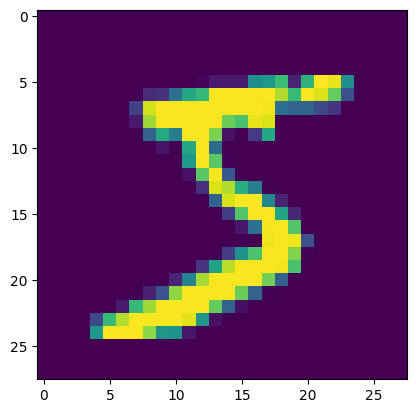

In [58]:
plt.imshow(image.squeeze())

In [59]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [60]:
from torch.nn.modules.activation import ReLU
class MNSITModel(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()

    self.layer_1 = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.ReLU(),
    )
    self.layer_2 = nn.Sequential(
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_shape)
    )
  def forward(self,x):
    return self.layer_2(self.layer_1(x))

In [61]:
model_1 = MNSITModel(input_shape=28*28,hidden_units=32,output_shape=len(class_name)).to(device)

In [62]:
#Loss Fucntion and Optimizer
loss_fn = nn.CrossEntropyLoss()


In [63]:

optimizer = torch.optim.Adam(params = model_1.parameters(),lr=0.001)

In [64]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [65]:
def train_loop(model:torch.nn.Module,loss_fn,optimizer):
  avg_train_acc=0
  train_acc=0
  #training the model
  model.train()
  avg_training_loss=0
  acc = Accuracy(task="multiclass",num_classes=10)
  for x,y in train_data_loader:
    x, y = x.to(device), y.to(device)
    y_logits = model(x)

    train_loss = loss_fn(y_logits,y)
    avg_training_loss+=train_loss
    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()
    train_acc += acc(y_logits,y).item()

  avg_training_loss= train_loss/len(train_data_loader)
  avg_train_acc = train_acc/len(train_data_loader)
  return train_loss,avg_training_loss,avg_train_acc

In [66]:
def test_loop(model:torch.nn.Module,loss_fn,optimizer):
  model.eval()
  avg_testing_loss =0
  test_acc=0
  avg_test_acc=0
  acc = Accuracy(task="multiclass",num_classes=10)
  with torch.inference_mode():
    for x,y in test_data_loader:
        x, y = x.to(device), y.to(device)
        y_test_logits = model(x)

        test_loss = loss_fn(y_test_logits,y)
        avg_testing_loss+=test_loss.item()

        test_acc += acc(y_test_logits,y).item()

  avg_testing_loss = test_loss/len(test_data_loader)
  #print(testing_loss)
  avg_test_acc=test_acc/len(test_data_loader)
  return test_loss,avg_testing_loss,avg_test_acc

In [67]:
NUM_EPOCHS=10
training_loss = []
testing_loss = []
avg_training_loss=0
avg_testing_loss= 0
training_acc=[]
testing_acc = []
train_acc=0
test_acc=0
for epoch in tqdm(range(NUM_EPOCHS)):
  train_loss,avg_training_loss,train_acc= train_loop(model=model_1,loss_fn=loss_fn,optimizer=optimizer)
  training_loss.append(train_loss)
  training_acc.append(train_acc)
  test_loss,avg_testing_loss,test_acc= test_loop(model=model_1,loss_fn=loss_fn,optimizer=optimizer)
  testing_loss.append(test_loss)
  testing_acc.append(test_acc)
  print(f"Epoch:{epoch} | Train Loss:{train_loss} | Training Accuracy:{training_acc} | Testing Accuracy :{testing_acc}")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch:0 | Train Loss:0.4419688880443573 | Training Accuracy:[0.8837] | Testing Accuracy :[0.9328075079872205]
Epoch:1 | Train Loss:0.33778858184814453 | Training Accuracy:[0.8837, 0.93805] | Testing Accuracy :[0.9328075079872205, 0.9447883386581469]
Epoch:2 | Train Loss:0.3724166750907898 | Training Accuracy:[0.8837, 0.93805, 0.9514] | Testing Accuracy :[0.9328075079872205, 0.9447883386581469, 0.9501797124600639]
Epoch:3 | Train Loss:0.07877351343631744 | Training Accuracy:[0.8837, 0.93805, 0.9514, 0.9598166666666667] | Testing Accuracy :[0.9328075079872205, 0.9447883386581469, 0.9501797124600639, 0.9592651757188498]
Epoch:4 | Train Loss:0.01489873044192791 | Training Accuracy:[0.8837, 0.93805, 0.9514, 0.9598166666666667, 0.9661166666666666] | Testing Accuracy :[0.9328075079872205, 0.9447883386581469, 0.9501797124600639, 0.9592651757188498, 0.9623602236421726]
Epoch:5 | Train Loss:0.03954945132136345 | Training Accuracy:[0.8837, 0.93805, 0.9514, 0.9598166666666667, 0.9661166666666666, 

In [68]:
#prediction
model_1.eval()
with torch.inference_mode():
  for x,y in test_data_loader:
    x = x.to(device)
    y_logits = model_1(x)
    y_pred = torch.argmax(torch.softmax(y_logits,dim=1),dim=1)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

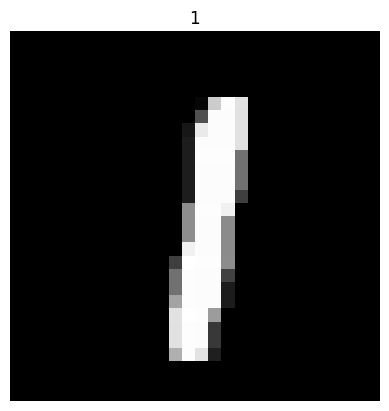

In [69]:
plt.imshow(x[0].cpu().squeeze(),cmap="gray")
plt.title(y_pred[0].item())
plt.axis(False)

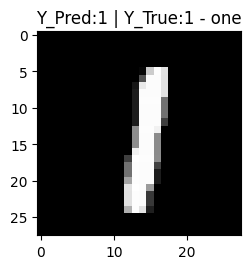

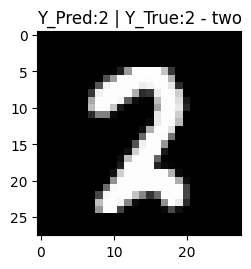

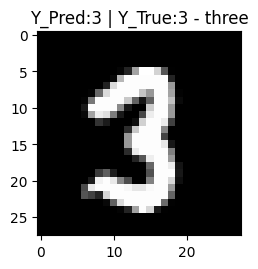

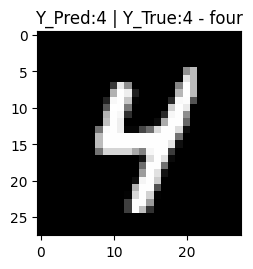

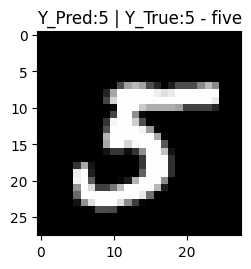

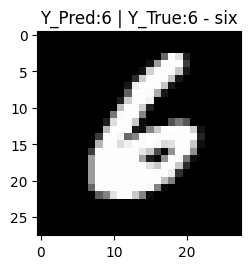

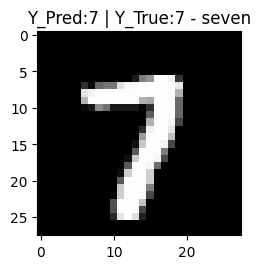

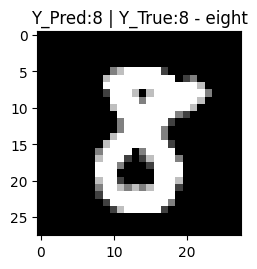

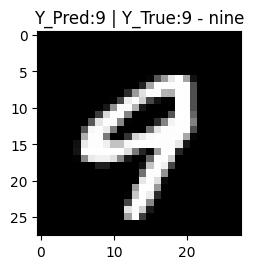

In [90]:
rows=3
cols=3
for i in range(rows*cols):
    plt.figure(figsize=(rows*3,cols*3))
    plt.subplot(rows, cols, i+1)
    plt.imshow(x[i].cpu().squeeze(0), cmap="gray")
    plt.title(f"Y_Pred:{y_pred[i].item()} | Y_True:{class_name[y[i].item()]}")

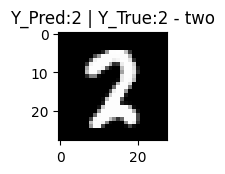

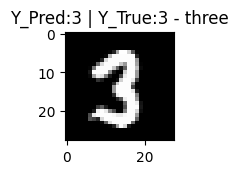

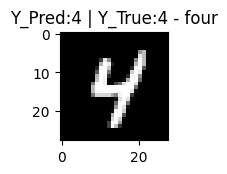

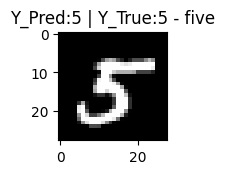

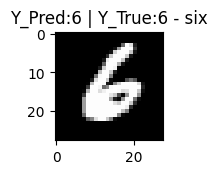

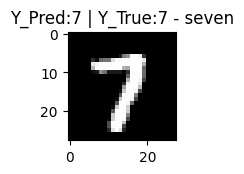

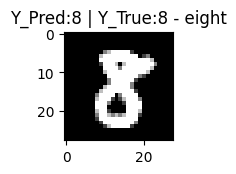

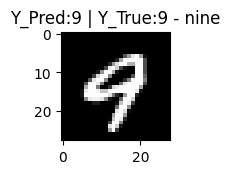

In [71]:
rows=3
cols=3
for i in range(1,rows*cols):
  plt.subplot(rows,cols,i)
  plt.imshow(x[i].cpu().squeeze(0),cmap="gray")
  plt.title(f"Y_Pred:{y_pred[i].item()} | Y_True:{class_name[y[i].item()]}")
  plt.show()

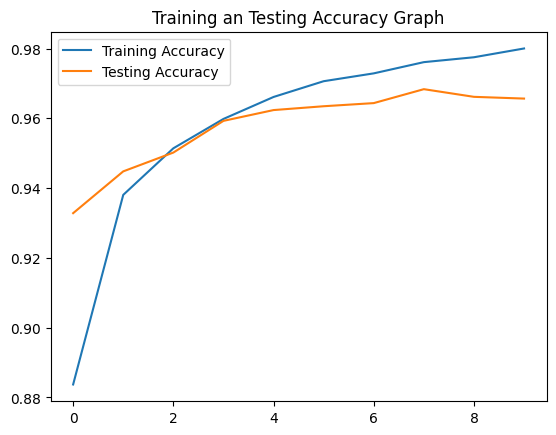

In [72]:
plt.plot(range(NUM_EPOCHS),training_acc,label="Training Accuracy")
plt.plot(range(NUM_EPOCHS),testing_acc,label="Testing Accuracy")
plt.legend()
plt.title("Training an Testing Accuracy Graph")
plt.show()

In [73]:
print(x.shape)

torch.Size([16, 1, 28, 28])


In [74]:
class MNSITModels(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()

    self.conv_layer_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,kernel_size=3,stride=1,padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
    )
    self.conv_layer_2 = nn.Sequential(
         nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classfier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*4*4,out_features=output_shape)
    )
  def forward(self,x):
    return self.classfier(self.conv_layer_2(self.conv_layer_1(x)))

In [75]:
model_2 = MNSITModels(input_shape=1,hidden_units=64,output_shape=len(class_name)).to(device)

In [76]:
model_2

MNSITModels(
  (conv_layer_1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer_2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classfier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=10, bias=True)
  )
)

In [77]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [78]:
x.shape

torch.Size([16, 1, 28, 28])

In [79]:
print(len(train_data_loader))

x, y = next(iter(train_data_loader))
print(x.shape)

1875
torch.Size([32, 1, 28, 28])


In [80]:
loss_fn = nn.CrossEntropyLoss().to(device)

In [81]:
opitmizer = torch.optim.Adam(model_2.parameters(),lr=0.001)

In [82]:
train_data_loader.batch_size

32

In [83]:
def train_loop_model_2(model:torch.nn.Module,loss_fn,optimizer):
  model.train()
  total_train_loss = 0
  total_train_acc = 0
  acc = Accuracy(task="multiclass",num_classes=10).to(device)

  for x,y in train_data_loader:
    x, y = x.to(device), y.to(device)
    y_logits = model(x)
    train_loss = loss_fn(y_logits,y)
    total_train_loss+=train_loss.item()

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    total_train_acc += acc(y_logits,y).item()

  avg_train_loss = total_train_loss/len(train_data_loader)
  avg_train_acc = total_train_acc/len(train_data_loader)
  return avg_train_loss, avg_train_acc

In [84]:
def test_loop_model_2(model:torch.nn.Module,loss_fn,optimizer):
  model.eval()
  total_test_loss = 0
  total_test_acc = 0
  acc = Accuracy(task="multiclass",num_classes=10).to(device)

  with torch.inference_mode():
    for x,y in test_data_loader:
        x, y = x.to(device), y.to(device)
        y_test_logits = model(x)
        test_loss = loss_fn(y_test_logits,y)
        total_test_loss+=test_loss.item()
        total_test_acc += acc(y_test_logits,y).item()

  avg_test_loss = total_test_loss/len(test_data_loader)
  avg_test_acc = total_test_acc/len(test_data_loader)
  return avg_test_loss, avg_test_acc

In [85]:
NUM_EPOCHS=10
training_loss = []
testing_loss = []
training_acc=[]
testing_acc = []

for epoch in tqdm(range(NUM_EPOCHS)):
  print("------")
  train_loss, train_acc = train_loop_model_2(model=model_2,loss_fn=loss_fn,optimizer=opitmizer)
  training_loss.append(train_loss)
  training_acc.append(train_acc)

  test_loss, test_acc = test_loop_model_2(model=model_2,loss_fn=loss_fn,optimizer=opitmizer)
  testing_loss.append(test_loss)
  testing_acc.append(test_acc)

  print(f"Epoch: {epoch+1} | Train Loss: {train_loss:.4f} | Training Accuracy: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Testing Accuracy: {test_acc:.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

------
Epoch: 1 | Train Loss: 0.1262 | Training Accuracy: 0.9609 | Test Loss: 0.0375 | Testing Accuracy: 0.9872
------
Epoch: 2 | Train Loss: 0.0419 | Training Accuracy: 0.9870 | Test Loss: 0.0366 | Testing Accuracy: 0.9887
------
Epoch: 3 | Train Loss: 0.0299 | Training Accuracy: 0.9909 | Test Loss: 0.0348 | Testing Accuracy: 0.9886
------
Epoch: 4 | Train Loss: 0.0231 | Training Accuracy: 0.9928 | Test Loss: 0.0269 | Testing Accuracy: 0.9918
------
Epoch: 5 | Train Loss: 0.0190 | Training Accuracy: 0.9940 | Test Loss: 0.0324 | Testing Accuracy: 0.9904
------
Epoch: 6 | Train Loss: 0.0149 | Training Accuracy: 0.9951 | Test Loss: 0.0275 | Testing Accuracy: 0.9923
------
Epoch: 7 | Train Loss: 0.0121 | Training Accuracy: 0.9960 | Test Loss: 0.0260 | Testing Accuracy: 0.9921
------
Epoch: 8 | Train Loss: 0.0101 | Training Accuracy: 0.9968 | Test Loss: 0.0298 | Testing Accuracy: 0.9917
------
Epoch: 9 | Train Loss: 0.0100 | Training Accuracy: 0.9968 | Test Loss: 0.0407 | Testing Accuracy:

In [88]:
model_2.eval()
with torch.inference_mode():
  for x,y in test_data_loader:
    x = x.to(device)
    y_logits = model_2(x)
    y_pred_2 = torch.argmax(torch.softmax(y_logits,dim=1),dim=1)

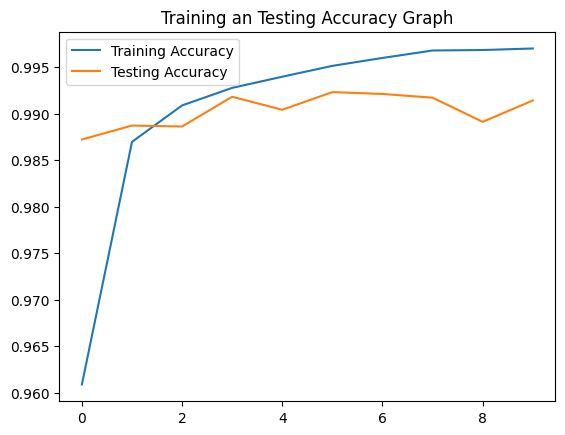

In [87]:
plt.plot(range(NUM_EPOCHS),training_acc,label="Training Accuracy")
plt.plot(range(NUM_EPOCHS),testing_acc,label="Testing Accuracy")
plt.legend()
plt.title("Training an Testing Accuracy Graph")
plt.show()

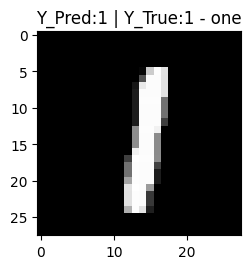

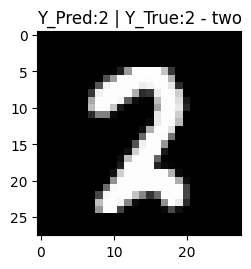

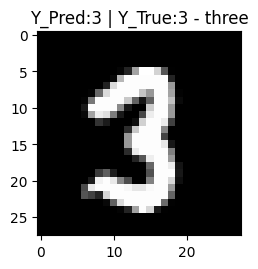

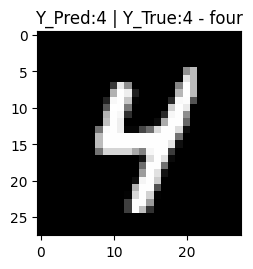

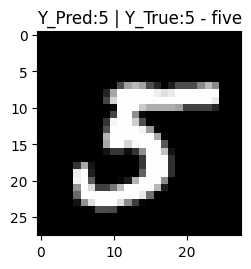

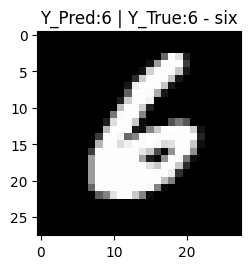

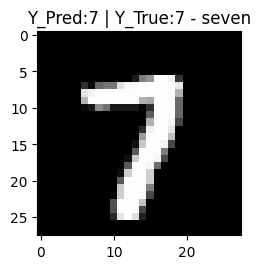

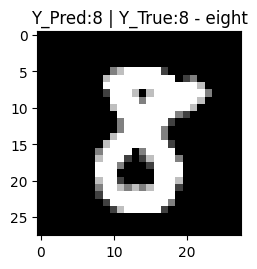

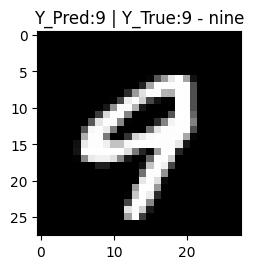

In [89]:
rows=3
cols=3
for i in range(rows*cols):
    plt.figure(figsize=(rows*3,cols*3))
    plt.subplot(rows, cols, i+1)
    plt.imshow(x[i].cpu().squeeze(0), cmap="gray")
    plt.title(f"Y_Pred:{y_pred_2[i].item()} | Y_True:{class_name[y[i].item()]}")

In [91]:
print(x.shape)
print(y.shape)
print(y_pred_2.shape)

torch.Size([16, 1, 28, 28])
torch.Size([16])
torch.Size([16])
